# Taller Práctico: Economía en Sistemas Hidrológicos
### Seminario ENCiT-UNAM | Sesión 2

**Objetivo:** Crear un semillero de ideas sobre cómo plantear preguntas de investigación que abarquen la relación entre sistemas hidrológicos y socio-económicos. Exploraremos empíricamente conceptos como los **recursos de uso común (Tragedia de los Comunes de Ostrom)**, las **externalidades**, y el papel de los **incentivos económicos** en la investigación y gestión del agua.

---

### 🌐 Fuentes de Datos (Exploración en vivo)
Para este taller, hemos recolectado y pre-procesado datos de tres instituciones clave. (Revisaremos estas plataformas en vivo):
1. **[CONAGUA - SINA (Sistema Nacional de Información del Agua)](https://sinav30.conagua.gob.mx:8080/SINA/)**: Polígonos de acuíferos, disponibilidad hídrica, y recaudación de tarifas.
2. **[INEGI - Censos Económicos](https://www.inegi.org.mx/temas/)**: Valor Agregado (riqueza generada) de los sectores Agrícola e Industrial a nivel municipal.
3. **[CONAPO - Índices de Marginación](https://www.gob.mx/conapo/documentos/indices-de-marginacion-2020-284372)**: Indicadores de rezago y vulnerabilidad social.

**Diccionario de Variables Principales:**
*   `Vol_Extraccion_Total`: Volumen total de agua concesionada extraída en el municipio (hm³). *Nuestra variable a predecir.*
*   `VA_Industrial` / `VA_Agricola`: Valor Agregado censal (miles de millones de pesos). Representa el tamaño/'riqueza' generada del sector.
*   `IM_2020`: Índice de Marginación (0-100). Mayor puntaje = mayor pobreza/carencias.
*   `POB_TOT`: Población total municipal (personas). Control demográfico esencial.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

## 1. Interacción: Hidrología en el Espacio vs Indicadores Económicos

Tenemos diferentes categorías de archivos: los geométricos por un lado (shapefiles) y numéricos por otro (CSVs o Excels). El primer paso es unirlos.

In [2]:
# ==========================================
# 🚀 CONFIGURACIÓN PARA GOOGLE COLAB
# Si estás usando Google Colab, descomenta las siguientes dos líneas
# para clonar el repositorio y acceder a los datos y shapefiles:
# ==========================================
# !git clone https://github.com/TU_USUARIO/Seminario_UNAM_EcoHidro.git
# %cd Seminario_UNAM_EcoHidro/04_Scripts

# 1. Cargamos el CSV económico maestro que les compartí para el curso
# pd.read_csv() lee un archivo de texto separado por comas (CSV) y lo convierte en un objeto tipo tabla (DataFrame)
df_master = pd.read_csv('data/master_ecohidro_2026.csv')

# groupby() agrupa los datos usando una columna clave (en este caso, el nombre del acuífero)
# .mean() calcula el promedio de las variables económicas para todos los municipios que están sobre ese mismo acuífero
# .reset_index() convierte el índice agrupado de vuelta a una columna normal para poder trabajar con ella
df_economia = df_master.groupby('NOM_ACUI')[['VA_Industrial', 'VA_Agricola', 'Tax_Ind_Millones', 'IM_2020']].mean().reset_index()
# .reset_index() convierte la variable agrupada (NOM_ACUI) de vuelta a una columna normal para poder hacer el cruce espacial (merge) más adelante.

# Mostramos las primeras 2 filas de la tabla de datos económicos para entender su estructura visualmente
display(df_economia.head(2))

# 2. Cargamos la geometría (Shapefile) de CONAGUA
# gpd.read_file() lee archivos espaciales que contienen polígonos, líneas o puntos en mapas
# .to_crs('EPSG:4326') estandariza el sistema de coordenadas a latitud y longitud clásicas (GPS)
shape_path = 'data/shapefiles/c_acuiferos_09112023/c_acuiferos_09112023_wgs84.shp'
gdf_acuiferos = gpd.read_file(shape_path).to_crs('EPSG:4326')

# Creamos la variable 'Salud del Acuífero' (Disponibilidad Neta)
# CONAGUA separa los números positivos y los negativos en dos columnas. Los fusionamos:
gdf_acuiferos['Disponibilidad_Neta'] = np.where(gdf_acuiferos['DMA_POSITI'] > 0, gdf_acuiferos['DMA_POSITI'], gdf_acuiferos['DMA_NEGATI'])
# NOTA: Los "acuíferos" representan exclusivamente aguas subterráneas (mantos freáticos).
# La extracción industrial/agrícola profunda es un ejemplo clásico de la Tragedia de los Comunes en zonas áridas.

print("\nDimensiones de los datos:")
print("Datos económicos (filas, columnas):", df_economia.shape)
print("Polígonos espaciales (filas, columnas):", gdf_acuiferos.shape)

# Mostramos las primeras 2 filas del mapa (nota la última columna especial llamada 'geometry')
display(gdf_acuiferos.head(2))

,NOM_ACUI,VA_Industrial,VA_Agricola,Tax_Ind_Millones,IM_2020
0,ACAPETAHUA,180.146100,15.703000,0.214976,51.755679
1,ACAXOCHITLÁN,536.978273,3.934909,1.605073,53.546911



Dimensiones de los datos:
Datos económicos (filas, columnas): (377, 5)
Polígonos espaciales (filas, columnas): (653, 6)


,NOM_ACUI,NOM_EDO,DMA_POSITI,DMA_NEGATI,geometry,Disponibilidad_Neta
0,GUADALUPE BAÃUELOS,ZACATECAS,0.0,-0.394701,"POLYGON ((-102.44638 22.64909, -102.44107 22.6...",-0.394701
1,CALERA,ZACATECAS,0.0,-67.260740,"POLYGON ((-102.64258 23.33527, -102.63898 23.2...",-67.260740


### ✍️ SU TURNO 1: Join Espacial (Fusionando Mapas y Datos)
Para poder mapear las variables económicas, necesitamos fusionar (merge) el mapa original (`gdf_acuiferos`) con nuestra nueva tabla de datos económicos (`df_economia`). 

💡 **Ayuda de Código:** Si alguna vez has usado `BUSCARV` (VLOOKUP) en Excel o un JOIN en SQL, en Python esto se hace usando la función `.merge()`. La sintaxis es:

`Tabla_Izquierda.merge(Tabla_Derecha, on='COLUMNA_CLAVE', how='TIPO_DE_UNION')`

*   **Tabla Derecha:** Es la tabla de datos que queremos "pegarle" al mapa (en nuestro caso, `df_economia`).
*   **on:** Es el nombre de la columna que ambas tablas tienen en común para saber qué fila va con qué fila. Si revisas arriba, ambas tablas tienen el nombre del acuífero en la columna **`'NOM_ACUI'`**.
*   **how:** Significa cómo queremos hacer la unión. Usaremos **`'left'`** para indicar que queremos conservar *todo* nuestro mapa (la tabla izquierda), incluso si a algún acuífero le faltan datos económicos.

In [3]:
# RELLENA EL ESPACIO EN BLANCO ('________') PARA UNIR LAS BASES
gdf_final = gdf_acuiferos.merge(________, on='________', how='________')

# Verificamos si las nuevas columnas (VA_Industrial, etc) ya están en el mapa
gdf_final.head(2)

,NOM_ACUI,NOM_EDO,DMA_POSITI,DMA_NEGATI,geometry,Disponibilidad_Neta,VA_Industrial,VA_Agricola,Tax_Ind_Millones,IM_2020
0,GUADALUPE BAÃUELOS,ZACATECAS,0.0,-0.394701,"POLYGON ((-102.44638 22.64909, -102.44107 22.6...",-0.394701,NaN,NaN,NaN,NaN
1,CALERA,ZACATECAS,0.0,-67.260740,"POLYGON ((-102.64258 23.33527, -102.63898 23.2...",-67.260740,78.364667,0.0,4.18692,56.10645


## 2. Cartografía Económica: Exploremos la Geografía de la Riqueza y la Disponibilidad Hídrica

Con nuestra base fusionada, comencemos a hacernos preguntas para visualizar. ¿Dónde están los problemas? ¿Dónde está el 'capital'?

⚠️ **Nota (Stock vs. Flujo):** La variable *Disponibilidad Neta* mide el **Balance Hídrico Anual** ($hm^3/\text{año}$), no el agua total acumulada (el stock). Un déficit (rojo) indica sobreexplotación: estamos extrayendo más agua de la que se logra infiltrar en un año.

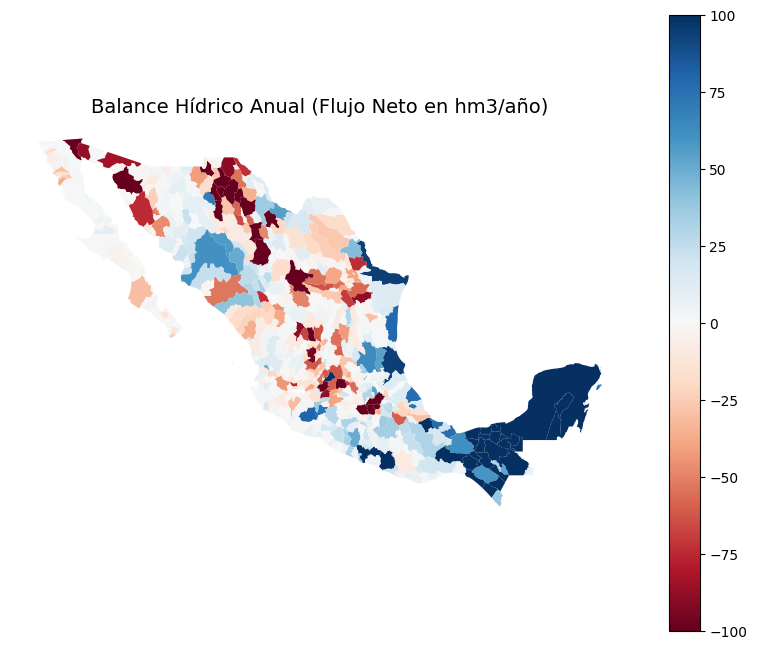

In [4]:
# MAPA 1: Balance Hídrico (Stock vs. Flujo)
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 8))

# mcolors.TwoSlopeNorm: Función estética de Matplotlib. Fuerza a que la escala de colores tenga su centro exacto en 0 (blanco).
# Topamos los valores (vmin=-100, vmax=100) para que los colores resalten y no se saturen por valores atípicos extremos.
norm = mcolors.TwoSlopeNorm(vmin=-100, 
                            vcenter=0, 
                            vmax=100)

# Trazamos el mapa usando la paleta RdBu (Rojo para negativos/déficit, Azul para positivos/superávit)
gdf_final.plot(column='Disponibilidad_Neta', cmap='RdBu', ax=ax, legend=True,
               norm=norm, missing_kwds={'color': 'lightgrey'}, edgecolor='none')

ax.set_title("Balance Hídrico Anual (Flujo Neto en hm3/año)", fontsize=14)
ax.set_axis_off()
plt.show()

# NOTA: El DataViz nos permite obtener intuiciones geográficas rápidas ("semilleros de ideas").
# Visualmente podemos intuir dónde coinciden las zonas rojas con los polos industriales, antes de modelar una regresión.

### ✍️ TU TURNO 2: Mapeando la externalidad
La externalidad de la que habla Ostrom ocurre cuando hay incentivos para sobre-extraer agua. Vamos a graficar la riqueza.

En el código de abajo, cambia la columna para mapear el **`VA_Industrial`** (riqueza manufacturera) o el **`VA_Agricola`**. 
*Pregúntate: ¿Ves algún patrón o sobreposición espacial entre la concentración de la riqueza y la disponibilidad hídrica del mapa anterior?*

💡 **Ayuda de Código (Geopandas):** Cuando usamos `.plot()` en mapas de Python, el argumento `column='...'` le indica al programa qué columna de nuestra tabla debe usar para pintar el mapa (mapa coroplético).

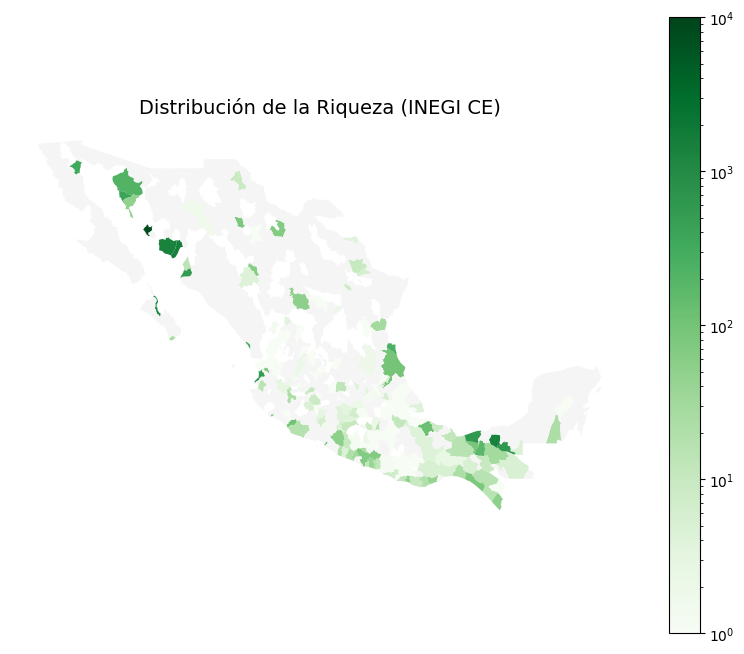

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

# CAMBIA 'VA_Industrial' POR 'VA_Industrial' o 'VA_Agricola'
# Nota: Usamos LogNorm (escala logarítmica, estética) para que los colores no se saturen por culpa de 3 o 4 municipios ultra-ricos. (LogNorm) porque la riqueza está muy concentrada
from matplotlib.colors import LogNorm

gdf_final.plot(column='________', cmap='Greens', ax=ax, 
               norm=LogNorm(vmin=1, vmax=10000), legend=True,
               missing_kwds={'color': 'whitesmoke'}, edgecolor='none')

ax.set_title("Distribución de la Riqueza (INEGI CE)", fontsize=14)
ax.set_axis_off()
plt.show()

## 3. Econometría: Poniendo a Prueba una Hipótesis

Un mapa no basta para dar solución a una pregunta de investigación. Encontrar y analizar correlaciones es fundamental. Una librería estándar en Python para esto es `statsmodels`.

Vamos a correr una regresión OLS (Mínimos Cuadrados Ordinarios) a nivel municipal para investigar cómo la **Marginación**, la **Riqueza Agrícola** y la **Población** nos ayudan a predecir matemáticamente cuánto volumen de agua se extrae en ese municipio.

**Ecuación Explícita:**
$$ \ln(VolExtraccion_i) = \beta_0 + \beta_1 \ln(Riqueza_i) + \beta_2 Marginacion_i + \beta_3 \ln(Poblacion_i) + \epsilon_i $$

In [6]:
# Preparamos variables limpias sin nulos (incluyendo Población para minimizar el Sesgo de Variables Omitidas [OVB])
df_reg = df_master[['Vol_Extraccion_Total', 'VA_Industrial', 'IM_2020', 'POB_TOT']].dropna()
df_reg = df_reg[(df_reg['Vol_Extraccion_Total'] > 0) & (df_reg['VA_Industrial'] >= 0)]  # Quitamos nulos y pérdidas negativas para permitir logaritmos

# --- TRANSFORMACIÓN LOGARÍTMICA (Elasticidad) ---
# TRANSFORMACIÓN LOGARÍTMICA (Log-Log)
# Económicamente, usar logaritmos nos permite calcular ELASTICIDADES.
# Si β = 0.2, significa que un aumento del 1% en Riqueza causa un aumento del 0.2% en Extracción de agua.
# Usamos np.log1p (que es log(x+1)) para evitar errores matemáticos con los municipios que tienen 0 industria.
df_reg['log_Vol_Extraccion'] = np.log1p(df_reg['Vol_Extraccion_Total'])
df_reg['log_VA_Industrial'] = np.log1p(df_reg['VA_Industrial'])
df_reg['log_POB_TOT'] = np.log1p(df_reg['POB_TOT'])

# Definimos Y (lo que queremos predecir) y X (predictores logarítmicos)
y = df_reg['log_Vol_Extraccion']
X = sm.add_constant(df_reg[['log_VA_Industrial', 'IM_2020', 'log_POB_TOT']]) # IM_2020 ya es un índice, no requiere logaritmo

# Corremos el modelo OLS (Mínimos Cuadrados Ordinarios)
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:     log_Vol_Extraccion   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     375.2
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          6.24e-195
Time:                        15:29:57   Log-Likelihood:                -3529.7
No. Observations:                2095   AIC:                             7067.
Df Residuals:                    2091   BIC:                             7090.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -7.6183      0.61

### ✍️ TU TURNO 3: El Contraste Agrícola
¿Qué pasa si hacemos la misma regresión, pero en lugar del Valor Agregado Industrial usamos el **`VA_Agricola`**?

Copia el código de la celda de arriba, pégalo en la celda de abajo y haz el cambio.

**Preguntas finales:**
1. ¿El coeficiente del valor agregado agrícola es mayor o menor que el industrial?
2. Fíjate en el p-value (P>|t|), ¿sigue siendo estadísticamente significativo?
3. Recordando la *Tragedia de los Comunes*, si la agricultura es el mayor extractor pero la mayoría de sus pozos no tienen medidor volumétrico, ¿de qué sirve saber que es estadísticamente el sector de mayor impacto si físicamente no podemos cobrarles una tarifa?

💡 **Ayuda de Código (Pasos para replicar el modelo):**
1. Copia todo el bloque de código de la regresión anterior.
2. Pégalo en la celda de abajo.
3. Busca todas las menciones a `VA_Industrial` y cámbialas por `VA_Agricola`. ¡Ten cuidado! Debes cambiarlo tanto en el filtro inicial (`.dropna()`), como en la transformación logarítmica (`np.log1p`), y al definir las variables `X`.

In [7]:
# PEGA Y MODIFICA AQUÍ EL CÓDIGO DE LA REGRESIÓN DE ARRIBA
# TIP: Cambia 'VA_Industrial' por 'VA_Agricola'

=== REGRESIÓN LOG-LOG: VOLUMEN VS AGRICULTURA ===
                            OLS Regression Results                            
Dep. Variable:     log_Vol_Extraccion   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     440.7
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          8.14e-222
Time:                        15:29:57   Log-Likelihood:                -3464.0
No. Observations:                2093   AIC:                             6936.
Df Residuals:                    2089   BIC:                             6959.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

## 4. El Peligro del Sesgo de Variable Omitida, OVB (Rigor Econométrico)
Es muy fácil confundir correlación con causalidad. Si ignoramos que los desiertos del norte
tienen naturalmente menos agua que las selvas del sur, el modelo le "echa la culpa" a la
industria por algo que en realidad es geografía/clima.

**Solución: Efectos Fijos por Región Hidrológico-Administrativa (RHA)**
Insertamos *dummies* por RHA para que el modelo compara municipios dentro de la misma región climática,
no entre el Noroeste árido y el trópico húmedo.


Adicionalmente, como los municipios vecinos comparten el mismo acuífero, sus errores
están correlacionados. Usamos **clustering de errores estándar a nivel Acuífero** para
no inflar artificialmente nuestra confianza estadística.

### ✍️ TU TURNO 4: Ensamblando el Modelo Final
El código de abajo es el motor econométrico definitivo, pero le faltan 3 piezas clave. Úsalo como plantilla y rellena los huecos con estas pistas:
1. **Logaritmos:** Recuerda usar `np.log1p(columna)` para crear las variables `log_Agr`, `log_Ind` y `log_Pob`.
2. **Dummies:** Para crear las variables indicadoras de clima, usa `dummies = pd.get_dummies(df_reg_rigor['rha'], prefix='RHA', drop_first=True)`.
3. **Clustering:** Al correr el `.fit()`, tienes que decirle a statsmodels que agrupe los errores por acuífero: `.fit(cov_type='cluster', cov_kwds={'groups': df_reg_rigor['NOM_ACUI']})`.

In [8]:
# ============================================================
# MODELO RIGUROSO: Modelo Log-Log + Efectos Fijos RHA + Clustering
# ============================================================

df_reg_rigor = df_master[['Vol_Extraccion_Total', 'VA_Agricola', 'VA_Industrial', 'IM_2020', 'POB_TOT',
                           'rha', 'NOM_ACUI']].dropna()
df_reg_rigor = df_reg_rigor[(df_reg_rigor['Vol_Extraccion_Total'] > 0) & (df_reg_rigor['VA_Agricola'] >= 0) & (df_reg_rigor['VA_Industrial'] >= 0)]

# 2. Transformación Logarítmica
# ________ ESPACIO PARA TU CÓDIGO (Calcula el np.log1p() para Agr, Ind y Pob) ________


# 3. Efectos Fijos por Región Hidrológico-Administrativa (rha)
# ________ ESPACIO PARA TU CÓDIGO (Usa pd.get_dummies) ________


# 4. Corremos el modelo con clustering de errores a nivel Acuífero
y_rigor = df_reg_rigor['log_Vol']
# ________ ESPACIO PARA TU CÓDIGO (define X_rigor y corre sm.OLS con cov_type='cluster') ________


# 5. Resultados comparativos
# print(f"=== R² MODELO RIGUROSO (Log-Log + RHA + POB): {modelo_rigor.rsquared:.3f} ===")

=== R² MODELO RIGUROSO (Log-Log + RHA + POB): 0.504 ===

INTERPRETACIÓN DE ELASTICIDADES (Coeficientes principales):
            coef    std err       z    P>|z|    [0.025    0.975]
-------  -------  ---------  ------  -------  --------  --------
const    -5.4497      1.059  -5.147    0        -7.525    -3.374
log_Pob   0.2824      0.048   5.892    0         0.188     0.376
log_Agr   0.2147      0.033   6.431    0         0.149     0.28
log_Ind   0.0752      0.024   3.079    0.002     0.027     0.123
IM_2020   0.0639      0.015   4.378    0         0.035     0.092

CONCLUSIÓN PEDAGÓGICA:
- El R-cuadrado saltó al ~50%. ¡Explicamos la mitad de la varianza en la extracción de agua en México!
- Elasticidad Agrícola (0.21): Por cada 1% que crece la riqueza agrícola, la extracción sube 0.21%.
- Elasticidad Industrial (0.07): Por cada 1% que crece la industria, la extracción sube 0.07%.
-> La industria sí importa, pero el 'hambre' de agua del agro es 3 veces mayor por cada punto porcentual de